# Instacart SparkSQL

Cấu trúc chính:
1. Tải các thư viện cần thiết.
2. Khởi tạo Spark Session.
3. Đọc dữ liệu và tạo TempView.
4. Thực hiện các truy vấn Spark SQL và trực quan hóa EDA.

## 1. Tải các thư viện cần thiết

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys

from pathlib import Path
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, DoubleType
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid")

print("Imports OK")

Imports OK


## 2. Khởi tạo Spark Session


In [17]:
import os
from pyspark.sql import SparkSession

# Kiểm tra SPARK_HOME có hợp lệ hay không
# Nếu không tìm thấy spark-submit thì để PySpark tự cấu hình
if "SPARK_HOME" in os.environ:
    spark_submit_path = os.path.join(
        os.environ["SPARK_HOME"],
        "bin",
        "spark-submit"
    )

    if not os.path.exists(spark_submit_path):
        print(f"SPARK_HOME không hợp lệ: {os.environ['SPARK_HOME']}")
        del os.environ["SPARK_HOME"]
        print("Đã xóa SPARK_HOME để PySpark tự cấu hình.")


# Lấy số luồng CPU hiện có
num_cores = os.cpu_count() or 8

# Đặt số partition theo số luồng CPU
optimal_partitions = num_cores

spark = (
    SparkSession.builder
    .appName("Instacart_Local_Analysis")
    .master("local[*]")                    # sử dụng toàn bộ CPU
    .config("spark.driver.host", "localhost")

    # Cấu hình bộ nhớ
    .config("spark.driver.memory", "4g")
    .config("spark.memory.fraction", "0.7")
    .config("spark.memory.storageFraction", "0.3")

    # Cấu hình song song và shuffle
    .config("spark.default.parallelism", str(optimal_partitions))
    .config("spark.sql.shuffle.partitions", str(optimal_partitions))

    # Bật Adaptive Query Execution
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")

    # Giảm log và tối ưu garbage collection
    .config("spark.ui.showConsoleProgress", "false")
    .config(
        "spark.driver.extraJavaOptions",
        "-XX:+UseG1GC "
        "-XX:InitiatingHeapOccupancyPercent=35 "
        "-Dlog4j.rootCategory=ERROR,console"
    )

    # Kết nối HDFS
    .config("spark.hadoop.fs.defaultFS", "hdfs://namenode:9000")

    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print("\nSparkSession khởi tạo thành công")
print(f"Version : {spark.version}")
print(f"App     : {spark.sparkContext.appName}")
print(f"Master  : {spark.sparkContext.master}")
print(f"CPU     : {num_cores} threads")
print(f"Shuffle : {optimal_partitions} partitions")

ConnectionRefusedError: [Errno 111] Connection refused

## 3. Đọc dữ liệu và tạo TempViews

Đọc 6 bảng CSV, chuẩn hóa tên/kiểu dữ liệu quan trọng, gộp bảng `prior` và `train`

In [3]:
BASE = "hdfs://namenode:9000/instacart/raw"

# Tùy chọn chung khi đọc CSV
csv_options = {
    "header": "true",
    "inferSchema": "true",
    "quote": '"',
    "escape": '"',
    "multiLine": "true"
}

# Đọc orders.csv
orders_df = (
    spark.read
    .options(**csv_options)
    .csv(f"{BASE}/orders.csv")
    .withColumnRenamed(
        "days_since_prior_order",
        "days_since_prior"
    )
)

# Đọc order-product tables
order_products_prior_df = (
    spark.read
    .options(**csv_options)
    .csv(f"{BASE}/order_products__prior.csv")
)

order_products_train_df = (
    spark.read
    .options(**csv_options)
    .csv(f"{BASE}/order_products__train.csv")
)

# products.csv có thể gây lỗi inferSchema nên dùng schema tường minh
from pyspark.sql.types import (
    StructType,
    StructField,
    IntegerType,
    StringType,
)

products_schema = StructType([
    StructField("product_id", IntegerType(), True),
    StructField("product_name", StringType(), True),
    StructField("aisle_id", IntegerType(), True),
    StructField("department_id", IntegerType(), True),
])

products_df = (
    spark.read
    .options(
        header="true",
        quote='"',
        escape='"',
        multiLine="true"
    )
    .schema(products_schema)
    .csv(f"{BASE}/products.csv")
)

# Đọc bảng danh mục
aisles_df = (
    spark.read
    .options(**csv_options)
    .csv(f"{BASE}/aisles.csv")
)

departments_df = (
    spark.read
    .options(**csv_options)
    .csv(f"{BASE}/departments.csv")
)

# Chuẩn hóa kiểu dữ liệu
orders_df = (
    orders_df
    .withColumn(
        "days_since_prior",
        F.col("days_since_prior").cast(DoubleType())
    )
    .withColumn(
        "order_dow",
        F.col("order_dow").cast(DoubleType())
    )
    .withColumn(
        "order_hour_of_day",
        F.col("order_hour_of_day").cast(DoubleType())
    )
)

aisles_df = aisles_df.withColumn(
    "aisle_id",
    F.col("aisle_id").cast(IntegerType())
)

departments_df = departments_df.withColumn(
    "department_id",
    F.col("department_id").cast(IntegerType())
)

# Gộp toàn bộ order-product
order_products_all_df = (
    order_products_prior_df
    .union(order_products_train_df)
)

# Đăng ký TempView để dùng SQL
orders_df.createOrReplaceTempView("orders")
order_products_prior_df.createOrReplaceTempView("order_products_prior")
order_products_train_df.createOrReplaceTempView("order_products_train")
order_products_all_df.createOrReplaceTempView("order_products_all")
products_df.createOrReplaceTempView("products")
aisles_df.createOrReplaceTempView("aisles")
departments_df.createOrReplaceTempView("departments")

print("Đọc dữ liệu và đăng ký TempViews thành công!")

# Kiểm tra nhanh
products_df.show(3, truncate=False)

print("products schema:")
products_df.printSchema()

Đọc dữ liệu và đăng ký TempViews thành công!
+----------+------------------------------------+--------+-------------+
|product_id|product_name                        |aisle_id|department_id|
+----------+------------------------------------+--------+-------------+
|1         |Chocolate Sandwich Cookies          |61      |19           |
|2         |All-Seasons Salt                    |104     |13           |
|3         |Robust Golden Unsweetened Oolong Tea|94      |7            |
+----------+------------------------------------+--------+-------------+
only showing top 3 rows
products schema:
root
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- aisle_id: integer (nullable = true)
 |-- department_id: integer (nullable = true)



In [4]:
tables = {
    'orders':                orders_df,
    'order_products_prior':  order_products_prior_df,
    'order_products_train':  order_products_train_df,
    'order_products_all':    order_products_all_df,
    'products':              products_df,
    'aisles':                aisles_df,
    'departments':           departments_df,
}

print(f"{'Bảng':<30} {'Rows':>12} {'Cols':>6}")
print('-'*50)
for name, df in tables.items():
    r = df.count(); c = len(df.columns)
    print(f'{name:<30} {r:>12,} {c:>6}')

# In schema chi tiết từng bảng
for name, df in tables.items():
    print(f'\n === Schema: {name} ===')
    df.printSchema()

Bảng                                   Rows   Cols
--------------------------------------------------
orders                            3,421,083      7
order_products_prior             32,434,489      4
order_products_train              1,384,617      4
order_products_all               33,819,106      4
products                             49,688      4
aisles                                  134      2
departments                              21      2

 === Schema: orders ===
root
 |-- order_id: integer (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- eval_set: string (nullable = true)
 |-- order_number: integer (nullable = true)
 |-- order_dow: double (nullable = true)
 |-- order_hour_of_day: double (nullable = true)
 |-- days_since_prior: double (nullable = true)


 === Schema: order_products_prior ===
root
 |-- order_id: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- add_to_cart_order: integer (nullable = true)
 |-- reordered: integer (nul

In [5]:
# Tạo danh sách rỗng để lưu thống kê tổng quan của từng bảng.
summary_rows = []

for table_name, table_df in tables.items():
    row_count = table_df.count()
    column_count = len(table_df.columns)
    summary_rows.append((table_name, row_count, column_count))

summary_pdf = pd.DataFrame(summary_rows, columns=["table_name", "rows", "columns"])

display(summary_pdf)

for table_name, table_df in tables.items():
    print(f"\nSchema: {table_name}")
    table_df.printSchema()

,table_name,rows,columns
0,orders,3421083,7
1,order_products_prior,32434489,4
2,order_products_train,1384617,4
3,order_products_all,33819106,4
4,products,49688,4
5,aisles,134,2
6,departments,21,2



Schema: orders
root
 |-- order_id: integer (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- eval_set: string (nullable = true)
 |-- order_number: integer (nullable = true)
 |-- order_dow: double (nullable = true)
 |-- order_hour_of_day: double (nullable = true)
 |-- days_since_prior: double (nullable = true)


Schema: order_products_prior
root
 |-- order_id: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- add_to_cart_order: integer (nullable = true)
 |-- reordered: integer (nullable = true)


Schema: order_products_train
root
 |-- order_id: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- add_to_cart_order: integer (nullable = true)
 |-- reordered: integer (nullable = true)


Schema: order_products_all
root
 |-- order_id: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- add_to_cart_order: integer (nullable = true)
 |-- reordered: integer (nullable = true)


Schema: products
root
 |-- product_id: 

In [6]:
orders_null_exprs = [
    F.sum(F.col(column_name).isNull().cast("int")).alias(column_name)
    for column_name in orders_df.columns
]

orders_nulls_df = orders_df.select(orders_null_exprs)

orders_nulls_df.show(truncate=False)

+--------+-------+--------+------------+---------+-----------------+----------------+
|order_id|user_id|eval_set|order_number|order_dow|order_hour_of_day|days_since_prior|
+--------+-------+--------+------------+---------+-----------------+----------------+
|0       |0      |0       |0           |0        |0                |206209          |
+--------+-------+--------+------------+---------+-----------------+----------------+



## 4. Thực hiện các truy vấn Spark SQL và trực quan hóa EDA.

Mỗi phân tích bên dưới gồm 2 cell chính:
- **Cell Script**: chạy Spark SQL và tạo DataFrame kết quả.
- **Cell Chart**: chuyển kết quả nhỏ sang Pandas và vẽ biểu đồ.

In [7]:
# Thiết lập cấu hình hiển thị đồng bộ cho toàn bộ notebook
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica', 'Calibri']
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['grid.color'] = '#e2e2e2'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.5

COLOR_PRIMARY_PASTEL = "#8fa9c4"
COLOR_ACCENT_WARM = "#e6550d"
COLOR_ACCENT_COOL = "#2b8cbe"

### Query 1 - Tổng số đơn hàng theo thứ và giờ trong ngày

**Ý nghĩa:** Phân tích thời điểm khách hàng đặt hàng nhiều nhất để nhận diện khung giờ cao điểm.

**Kỹ thuật:** Truy vấn bảng `orders`, gom nhóm theo `order_dow` và `order_hour_of_day`, đếm số đơn hàng bằng `COUNT(*)`, đồng thời tính thêm `pct_of_total` bằng window function để biết mỗi ô ngày-giờ chiếm bao nhiêu phần trăm tổng đơn hàng.

In [8]:
df_orders_by_day_hour = spark.sql("""
    SELECT
        order_dow,
        CASE order_dow
            WHEN 0 THEN 'Sunday'
            WHEN 1 THEN 'Monday'
            WHEN 2 THEN 'Tuesday'
            WHEN 3 THEN 'Wednesday'
            WHEN 4 THEN 'Thursday'
            WHEN 5 THEN 'Friday'
            WHEN 6 THEN 'Saturday'
        END AS day_name,
        order_hour_of_day,
        COUNT(*) AS total_orders,
        -- Tính tỷ trọng của từng ô ngày-giờ trên tổng số đơn hàng.
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct_of_total
    FROM orders
    GROUP BY order_dow, order_hour_of_day
    ORDER BY order_dow, order_hour_of_day
""").cache()

pdf_orders_by_day_hour = df_orders_by_day_hour.toPandas()

display(pdf_orders_by_day_hour.head())

,order_dow,day_name,order_hour_of_day,total_orders,pct_of_total
0,0.0,Sunday,0.0,3936,0.12
1,0.0,Sunday,1.0,2398,0.07
2,0.0,Sunday,2.0,1409,0.04
3,0.0,Sunday,3.0,963,0.03
4,0.0,Sunday,4.0,813,0.02


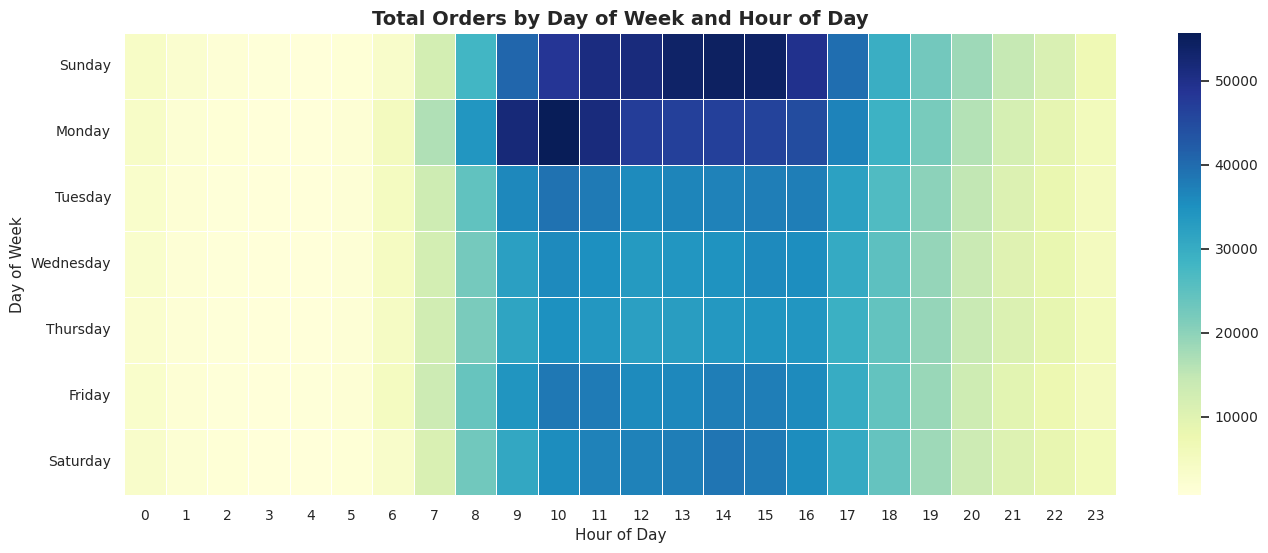

In [9]:
day_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

# Pivot dữ liệu để đưa về định dạng matrix cho heatmap
heatmap_data = pdf_orders_by_day_hour.pivot(index="day_name", columns="order_hour_of_day", values="total_orders")
heatmap_data = heatmap_data.reindex(day_order)
heatmap_data = heatmap_data.reindex(columns=range(24))

# Vẽ heatmap
plt.figure(figsize=(16, 6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Total Orders by Day of Week and Hour of Day", fontsize=14, fontweight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.show()

**Nhận xét:** Heatmap cho thấy nhu cầu đặt hàng tập trung rõ vào ban ngày, đặc biệt từ cuối buổi sáng đến chiều. Các ô màu đậm nằm nhiều ở Chủ Nhật và Thứ Hai, trong khi khung 0h–5h gần như là vùng thấp nhất. Điều này cho thấy hành vi đặt hàng của Instacart thiên về routine mua sắm đầu tuần/cuối tuần hơn là đặt rải đều trong ngày.

### Query 2 - Khoảng cách giữa hai lần đặt hàng

**Ý nghĩa:** Đo chu kỳ quay lại mua hàng của khách hàng thông qua số ngày giữa hai đơn liên tiếp. Biến này rất hữu ích khi phân tích retention, tần suất mua lại và phân khúc khách hàng.

**Kỹ thuật:** Sử dụng cột `days_since_prior` trong bảng `orders`; loại các dòng null vì đây là đơn đầu tiên của mỗi user, chưa có đơn trước đó để so sánh. Sau đó gom nhóm theo số ngày và đếm số đơn hàng ở từng mốc.

In [10]:
df_days_prior = spark.sql("""
    SELECT
        days_since_prior,
        COUNT(*) AS total_orders
    FROM orders
    WHERE days_since_prior > 0
    GROUP BY days_since_prior
    ORDER BY days_since_prior
""").cache()

pdf_days_prior = df_days_prior.toPandas()

display(pdf_days_prior)

,days_since_prior,total_orders
0,1.0,145247
1,2.0,193206
2,3.0,217005
3,4.0,221696
4,5.0,214503
5,6.0,240013
6,7.0,320608
7,8.0,181717
8,9.0,118188
9,10.0,95186


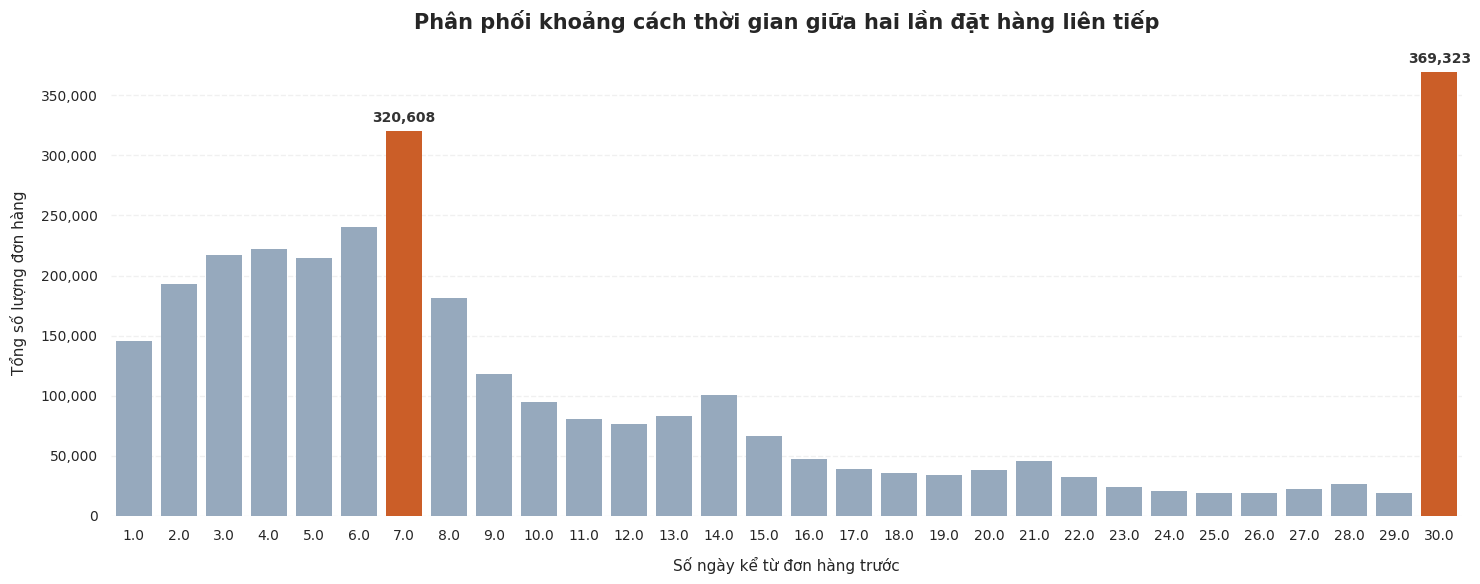

In [11]:
plt.figure(figsize=(15, 6))

colors = []
for x in pdf_days_prior["days_since_prior"]:
    if x in [7, 30]:
        colors.append(COLOR_ACCENT_WARM)
    else:
        colors.append(COLOR_PRIMARY_PASTEL)

ax = sns.barplot(
    data=pdf_days_prior,
    x="days_since_prior",
    y="total_orders",
    palette=colors,
    edgecolor="none"
)

for p in ax.patches:
    height = p.get_height()
    x_val = p.get_x() + p.get_width() / 2.
    # Chỉ hiển thị nhãn cho mốc 7 ngày và 30 ngày
    if int(p.get_x() + 0.5) in [6, 29]:
        ax.annotate(f'{height:,.0f}',
                    (x_val, height),
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold', color='#333333',
                    xytext=(0, 4), textcoords='offset points')

plt.title("Phân phối khoảng cách thời gian giữa hai lần đặt hàng liên tiếp", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Số ngày kể từ đơn hàng trước", labelpad=10)
plt.ylabel("Tổng số lượng đơn hàng", labelpad=10)

ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

**Nhận xét:** Phân phối có hai đỉnh rất rõ ở mốc **7 ngày** và **30 ngày**. Trong dataset này, mốc 7 ngày có **320,608 đơn**, còn mốc 30 ngày có **369,323 đơn**, cao nhất toàn bộ phân phối. Điều này phản ánh hai chu kỳ mua lại chính: mua hằng tuần và mua theo tháng, rất phù hợp để tạo nhóm khách hàng theo tần suất quay lại.

### Query 3 - Top 20 sản phẩm thường được thêm vào giỏ đầu tiên

**Ý nghĩa:** Tìm các sản phẩm mà hàng khách hàng thường chọn đầu tiên khi bắt đầu xây dựng giỏ hàng. Nhóm này thường là sản phẩm quen thuộc hoặc có nhu cầu mua lặp lại cao.

**Kỹ thuật:** Lọc `order_products_all` với `add_to_cart_order = 1`, join với `products` và `departments` để lấy tên sản phẩm và ngành hàng, sau đó đếm tần suất xuất hiện ở vị trí đầu tiên rồi lấy top 20.

In [12]:
df_first_in_cart = spark.sql("""
    SELECT
        p.product_id,
        p.product_name,
        d.department,
        COUNT(*) AS first_in_cart_count
    FROM order_products_all op
    JOIN products p ON op.product_id = p.product_id
    JOIN departments d ON p.department_id = d.department_id
    WHERE op.add_to_cart_order = 1
    GROUP BY p.product_id, p.product_name, d.department
    ORDER BY first_in_cart_count DESC
    LIMIT 20
""").cache()

pdf_first_in_cart = df_first_in_cart.toPandas()

display(pdf_first_in_cart)

,product_id,product_name,department,first_in_cart_count
0,24852,Banana,produce,115521
1,13176,Bag of Organic Bananas,produce,82877
2,27845,Organic Whole Milk,dairy eggs,32071
3,21137,Organic Strawberries,produce,28875
4,47209,Organic Hass Avocado,produce,24913
5,21903,Organic Baby Spinach,produce,24412
6,47766,Organic Avocado,produce,23393
7,19660,Spring Water,beverages,17552
8,16797,Strawberries,produce,17073
9,27966,Organic Raspberries,produce,14950


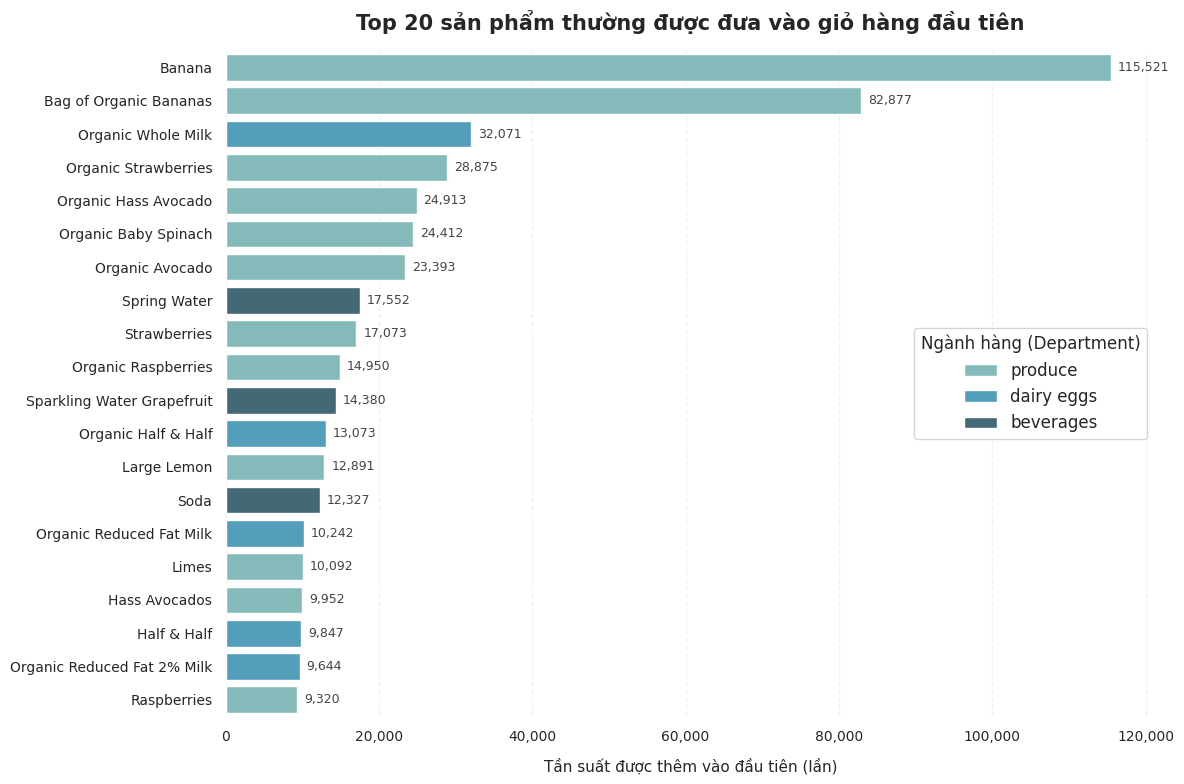

In [13]:
pdf_first_plot = pdf_first_in_cart.sort_values("first_in_cart_count", ascending=False)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=pdf_first_plot,
    x="first_in_cart_count",
    y="product_name",
    hue="department",
    dodge=False,
    palette="GnBu_d"
)

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:,.0f}',
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    fontsize=9, color='#444444',
                    xytext=(5, 0), textcoords='offset points')

plt.title("Top 20 sản phẩm thường được đưa vào giỏ hàng đầu tiên", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Tần suất được thêm vào đầu tiên (lần)", labelpad=10)
plt.ylabel("")
plt.legend(title="Ngành hàng (Department)", loc="center right", frameon=True, fontsize=12)

ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

**Nhận xét:** Nhóm sản phẩm được thêm đầu tiên bị chi phối mạnh bởi các mặt hàng thiết yếu. `Banana` đứng đầu với **115,521 lần**, tiếp theo là `Bag of Organic Bananas` với **82,877 lần**; sau đó mới đến `Organic Whole Milk`, `Organic Strawberries` và các sản phẩm produce, dairy khác. Điều này cho thấy các nhóm sản phẩm thường là sản phẩm đầu tiên để khách hàng bắt đầu giỏ hàng.

### Query 4 - Phân phối kích thước giỏ hàng

**Ý nghĩa:** Xác định một đơn hàng thường có bao nhiêu sản phẩm, từ đó hiểu quy mô basket phổ biến và phát hiện phần đuôi dài của các đơn hàng rất lớn.

**Kỹ thuật:** Tính `basket_size` bằng `COUNT(product_id)` trên từng `order_id` trong `order_products_all`.

In [14]:
df_basket_size = spark.sql("""
    WITH basket_sizes AS (
        SELECT
            order_id,
            COUNT(product_id) AS basket_size
        FROM order_products_all
        GROUP BY order_id
    )
    SELECT
        basket_size,
        COUNT(*) AS total_orders
    FROM basket_sizes
    GROUP BY basket_size
    ORDER BY basket_size
""").cache()

pdf_basket_size = df_basket_size.toPandas()

display(pdf_basket_size.head())


,basket_size,total_orders
0,1,163593
1,2,194361
2,3,215060
3,4,230299
4,5,237225


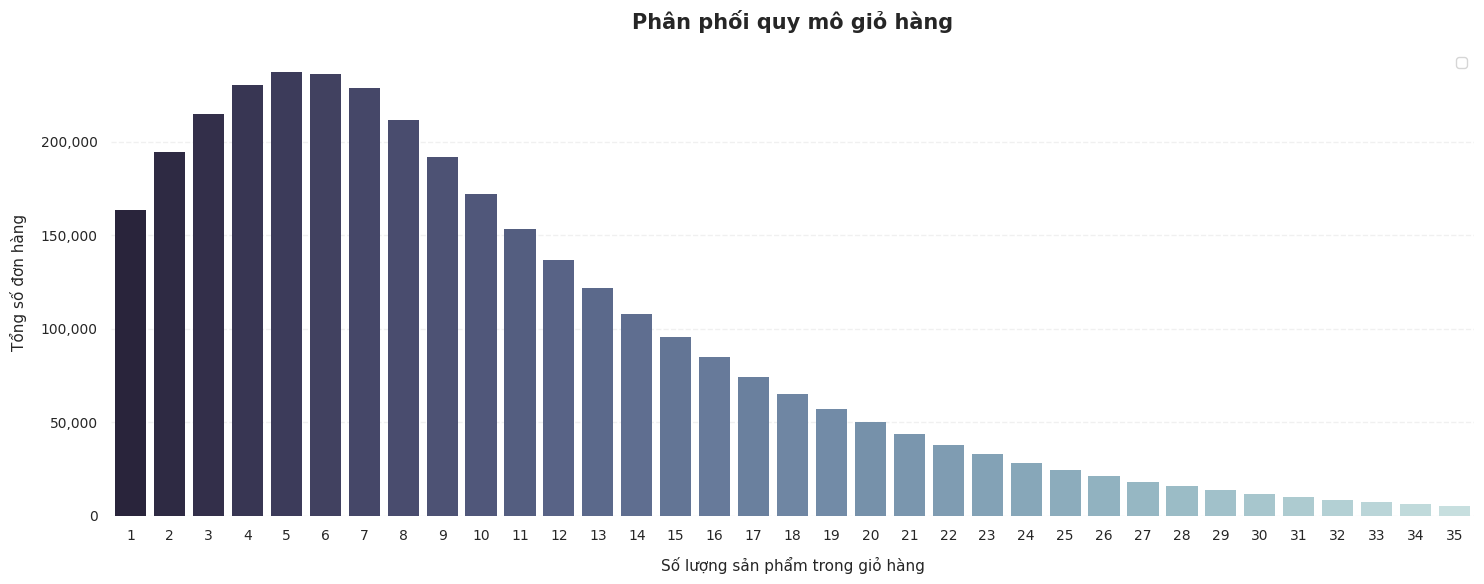

In [15]:
pdf_basket_plot = pdf_basket_size[pdf_basket_size["basket_size"] <= 35].copy()

plt.figure(figsize=(15, 6))

colors = sns.color_palette("ch:start=.2,rot=-.3_r", len(pdf_basket_plot))

ax = sns.barplot(
    data=pdf_basket_plot,
    x="basket_size",
    y="total_orders",
    palette=colors,
    edgecolor="none"
)

plt.title("Phân phối quy mô giỏ hàng", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Số lượng sản phẩm trong giỏ hàng", labelpad=10)
plt.ylabel("Tổng số đơn hàng", labelpad=10)
plt.legend(loc="upper right", frameon=True)

ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

**Nhận xét:** Phân phối basket size cho thấy phần lớn đơn hàng tập trung ở nhóm giỏ nhỏ đến trung bình. Trong các giá trị đầu, số đơn tăng dần từ giỏ 1 món (**163,593 đơn**) đến khoảng 5 món (**237,225 đơn**), sau đó biểu đồ cho thấy xu hướng giảm dần khi kích thước giỏ lớn hơn. Điều này phản ánh hành vi mua sắm phổ biến của Instacart là mua nhiều món trong một đơn, nhưng các giỏ hàng quá lớn chỉ chiếm phần nhỏ hơn trong tổng số đơn.

### Query 5 - Customer Journey theo số lần đặt hàng

**Ý nghĩa:** Theo dõi hành vi thay đổi theo từng lần mua của khách hàng: giỏ hàng trung bình có ổn định không và tỷ lệ sản phẩm mua lại tăng nhanh ở giai đoạn nào.

**Kỹ thuật:** Join `orders` với `order_products_all`, tính số món và số món reordered ở từng đơn hàng, sau đó gom theo `order_number`.

In [16]:
df_customer_journey = spark.sql("""
    WITH order_metrics AS (
        SELECT
            o.order_id,
            o.order_number,
            COUNT(op.product_id) AS basket_size,
            SUM(op.reordered) AS total_reordered
        FROM orders o
        JOIN order_products_all op ON o.order_id = op.order_id
        GROUP BY o.order_id, o.order_number
    )
    SELECT
        order_number,
        COUNT(order_id) AS total_orders,
        ROUND(AVG(basket_size), 2) AS avg_basket_size,
        -- Weighted reorder rate: tổng reordered / tổng sản phẩm ở cùng order_number.
        ROUND(SUM(total_reordered) * 100.0 / SUM(basket_size), 2) AS reorder_rate
    FROM order_metrics
    WHERE order_number <= 50
    GROUP BY order_number
    ORDER BY order_number
""").cache()

pdf_customer_journey = df_customer_journey.toPandas()

display(pdf_customer_journey.head())


ConnectionRefusedError: [Errno 111] Connection refused

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))

color_basket = "#2b5c8f"
line1 = ax1.plot(
    pdf_customer_journey["order_number"],
    pdf_customer_journey["avg_basket_size"],
    marker="o",
    color=color_basket,
    linewidth=2,
    markersize=6,
    label="Quy mô giỏ trung bình"
)
ax1.set_xlabel("Thứ tự đơn hàng của khách hàng (Order Number)", fontweight="bold", labelpad=10)
ax1.set_ylabel("")
ax1.tick_params(axis='y', labelcolor=color_basket)
ax1.yaxis.tick_right()
ax1.yaxis.set_label_position("right")
ax1.grid(True, linestyle="--", alpha=0.3)

ax2 = ax1.twinx()
color_reorder = COLOR_ACCENT_WARM
line2 = ax2.plot(
    pdf_customer_journey["order_number"],
    pdf_customer_journey["reorder_rate"],
    marker="s",
    color=color_reorder,
    linewidth=2,
    markersize=6,
    label="Tỷ lệ mua lại weighted (%)"
)
ax2.set_ylabel("")
ax2.tick_params(axis='y', labelcolor=color_reorder)
ax2.yaxis.tick_left()
ax2.yaxis.set_label_position("left")
ax2.grid(False)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="lower right", frameon=True)

plt.title("Sự thay đổi hành vi theo tần suất mua sắm", fontsize=15, fontweight="bold", pad=15)

sns.despine(ax=ax1, left=True, right=False, top=True, bottom=False)
sns.despine(ax=ax2, left=False, right=True, top=True, bottom=False)

fig.tight_layout()
plt.show()


**Nhận xét:** Ở đơn đầu tiên, reorder rate bằng **0%** vì chưa có lịch sử mua trước đó. Từ đơn thứ 2 trở đi, tỷ lệ mua lại tăng nhanh; kết quả trên dataset này thường cho thấy đơn thứ 2 khoảng **27.24%**, đơn thứ 3 khoảng **38.63%**, và đến đơn thứ 5 đã vượt **50%**. Trong khi đó, basket size trung bình dao động quanh khoảng 10 món, nghĩa là sự thay đổi lớn nhất theo journey nằm ở mức độ lặp lại sản phẩm quen thuộc hơn là số lượng món trong mỗi giỏ.

### Query 6 - So sánh sản phẩm Organic và Non-Organic

**Ý nghĩa:** So sánh quy mô bán ra và mức độ mua lại giữa nhóm sản phẩm có yếu tố “organic” và nhóm còn lại, từ đó đánh giá liệu organic có tạo loyalty tốt hơn hay không.

**Kỹ thuật:** Tạo nhãn nhanh bằng rule `LOWER(product_name) LIKE '%organic%'`. Sau đó tính `total_sold` bằng `COUNT(product_id)` và `reorder_rate` bằng tỷ lệ `SUM(reordered) / COUNT(product_id)`. Đây là heuristic dựa trên tên sản phẩm, không phải nhãn chính thức của dataset.

In [ ]:
df_organic = spark.sql("""
    WITH product_flags AS (
        SELECT
            op.product_id,
            op.reordered,
            CASE
                WHEN LOWER(p.product_name) LIKE '%organic%' THEN 'Organic'
                ELSE 'Non-Organic'
            END AS product_category
        FROM order_products_all op
        JOIN products p ON op.product_id = p.product_id
    )
    SELECT
        product_category,
        COUNT(product_id) AS total_sold,
        ROUND(SUM(reordered) * 100.0 / COUNT(product_id), 2) AS reorder_rate
    FROM product_flags
    GROUP BY product_category
    ORDER BY product_category
""").cache()

pdf_organic = df_organic.toPandas()

display(pdf_organic)

In [ ]:
pdf_organic_plot = pdf_organic.copy()
pdf_organic_plot["product_category"] = pd.Categorical(
    pdf_organic_plot["product_category"],
    categories=["Organic", "Non-Organic"],
    ordered=True,
)
pdf_organic_plot = pdf_organic_plot.sort_values("product_category")

# Thiết lập lát cắt tách nhẹ (explode) cho Organic để nhấn mạnh
explode_values = [0.08, 0]
colors_pie = ["#7fcdbb", COLOR_PRIMARY_PASTEL]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Biểu đồ tròn - Tỷ trọng sản lượng
wedges, texts, autotexts = axes[0].pie(
    pdf_organic_plot["total_sold"],
    labels=pdf_organic_plot["product_category"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors_pie,
    explode=explode_values,
    shadow=False,
    textprops=dict(color="#333333")
)

plt.setp(autotexts, size=10, weight="bold")
axes[0].set_title("Tỷ trọng sản lượng bán ra", fontsize=13, fontweight="bold", pad=10)

# 2. Biểu đồ cột - Tỷ lệ mua lại (Reorder Rate)
sns.barplot(
    data=pdf_organic_plot,
    x="product_category",
    y="reorder_rate",
    palette=colors_pie,
    ax=axes[1],
    edgecolor="none"
)
for index, value in enumerate(pdf_organic_plot["reorder_rate"]):
    axes[1].text(index, value / 2, f"{value:.1f}%", ha="center", va="center", color="#333333", fontweight="bold", fontsize=12)

axes[1].set_title("Tỷ lệ mua lại - Reorder Rate", fontsize=13, fontweight="bold", pad=10)
axes[1].set_ylabel("")
axes[1].set_xlabel("")

sns.despine(ax=axes[1], left=True, bottom=True)
plt.suptitle("Phân tích hành vi tiêu dùng: Sản phẩm Organic vs Non-Organic", fontsize=15, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

**Nhận xét:** Nhóm Non-Organic vẫn chiếm sản lượng lớn hơn nhiều với **23,162,774 lượt mua**, trong khi Organic có **10,656,332 lượt mua**. Tuy nhiên, Organic có reorder rate cao hơn (**63.54%** so với **56.92%**), cho thấy nhóm này tuy nhỏ hơn về volume nhưng có mức độ trung thành tốt hơn.

### Query 7 - Top 15 cặp sản phẩm volume cao thường mua chung

**Ý nghĩa:** Phát hiện các cặp sản phẩm thường xuất hiện chung trong cùng giỏ hàng phân loại theo sản phẩm Organic và Non-Organic

**Kỹ thuật:** Đầu tiên tính chỉ số sản phẩm gồm `total_purchases`, `total_unique_buyers` và `reorder_rate`, sau đó phân khúc sản phẩm thành `Chủ lực`, `Phổ thông`, `Tiềm năng` và `Cần kích cầu`. Tiếp theo, tạo các cặp sản phẩm bằng self-join trên cùng `order_id` với điều kiện `a.product_id < b.product_id` để tránh đếm trùng A-B và B-A. Bảng `product_pair_base` lưu thông tin hai sản phẩm, nhãn organic, phân khúc sản phẩm và `co_occurrence`. Sau đó, query top pair chỉ lấy các cặp mà cả hai sản phẩm đều có `total_purchases > 50000`.

In [ ]:
df_product_pair_base = spark.sql("""
    WITH product_metrics AS (
        SELECT
            op.product_id,
            COUNT(*) AS total_purchases,
            COUNT(DISTINCT o.user_id) AS total_unique_buyers,
            AVG(op.reordered) AS reorder_rate
        FROM order_products_all op
        JOIN orders o
            ON op.order_id = o.order_id
        GROUP BY op.product_id
    ),

    product_thresholds AS (
        SELECT
            percentile_approx(total_unique_buyers, 0.5) AS reach_median,
            percentile_approx(reorder_rate, 0.5) AS loyalty_median
        FROM product_metrics
        WHERE total_purchases >= 100
    ),

    product_segments AS (
        SELECT
            pm.product_id,
            p.product_name,
            p.department_id,
            d.department,
            pm.total_purchases,
            pm.total_unique_buyers,
            pm.reorder_rate,

            CASE
                WHEN LOWER(p.product_name) LIKE '%organic%' THEN 1
                ELSE 0
            END AS is_organic,

            CASE
                WHEN LOWER(p.product_name) LIKE '%organic%' THEN 'Organic'
                ELSE 'Non-Organic'
            END AS organic_label,

            CASE
                WHEN pm.total_unique_buyers >= pt.reach_median
                 AND pm.reorder_rate >= pt.loyalty_median THEN 'Chủ lực'

                WHEN pm.total_unique_buyers >= pt.reach_median
                 AND pm.reorder_rate < pt.loyalty_median THEN 'Phổ thông'

                WHEN pm.total_unique_buyers < pt.reach_median
                 AND pm.reorder_rate >= pt.loyalty_median THEN 'Tiềm năng'

                ELSE 'Cần kích cầu'
            END AS product_segment

        FROM product_metrics pm
        JOIN products p
            ON pm.product_id = p.product_id
        JOIN departments d
            ON p.department_id = d.department_id
        CROSS JOIN product_thresholds pt
    ),

    order_product_distinct AS (
        SELECT DISTINCT
            order_id,
            product_id
        FROM order_products_all
    ),

    pair_lines AS (
        SELECT
            a.order_id,
            a.product_id AS product_a_id,
            b.product_id AS product_b_id
        FROM order_product_distinct a
        JOIN order_product_distinct b
            ON a.order_id = b.order_id
           AND a.product_id < b.product_id
    )

    SELECT
        pa.product_id AS product_a_id,
        pb.product_id AS product_b_id,

        pa.product_name AS product_a,
        pb.product_name AS product_b,

        pa.department_id AS department_id_a,
        pb.department_id AS department_id_b,

        pa.department AS department_a,
        pb.department AS department_b,

        pa.is_organic AS is_organic_a,
        pb.is_organic AS is_organic_b,

        pa.organic_label AS organic_label_a,
        pb.organic_label AS organic_label_b,

        CASE
            WHEN pa.is_organic = 1 AND pb.is_organic = 1 THEN 'Both Organic'
            WHEN pa.is_organic = 0 AND pb.is_organic = 0 THEN 'Both Non-Organic'
            ELSE 'Mixed Organic and Non-Organic'
        END AS organic_pair_type,

        pa.product_segment AS segment_a,
        pb.product_segment AS segment_b,

        pa.total_purchases AS total_purchases_a,
        pb.total_purchases AS total_purchases_b,

        pa.total_unique_buyers AS total_unique_buyers_a,
        pb.total_unique_buyers AS total_unique_buyers_b,

        ROUND(pa.reorder_rate * 100.0, 2) AS reorder_rate_a,
        ROUND(pb.reorder_rate * 100.0, 2) AS reorder_rate_b,

        COUNT(*) AS co_occurrence

    FROM pair_lines pl
    JOIN product_segments pa
        ON pl.product_a_id = pa.product_id
    JOIN product_segments pb
        ON pl.product_b_id = pb.product_id

    GROUP BY
        pa.product_id,
        pb.product_id,
        pa.product_name,
        pb.product_name,
        pa.department_id,
        pb.department_id,
        pa.department,
        pb.department,
        pa.is_organic,
        pb.is_organic,
        pa.organic_label,
        pb.organic_label,
        pa.product_segment,
        pb.product_segment,
        pa.total_purchases,
        pb.total_purchases,
        pa.total_unique_buyers,
        pb.total_unique_buyers,
        pa.reorder_rate,
        pb.reorder_rate
""").cache()

df_product_pair_base.createOrReplaceTempView("product_pair_base")

In [ ]:
# Từ bảng dùng chung, lấy top 15 cặp sản phẩm volume cao thường được mua chung.
df_product_pairs = spark.sql("""
    SELECT
        product_a,
        product_b,
        is_organic_a,
        is_organic_b,
        organic_pair_type,
        segment_a,
        segment_b,
        -- Số lần xuất hiện chung.
        co_occurrence
    FROM product_pair_base
    -- Top product pair chỉ xét hai sản phẩm volume cao để tránh nhiễu từ sản phẩm quá ngách.
    WHERE total_purchases_a > 50000
      AND total_purchases_b > 50000
    ORDER BY co_occurrence DESC
    LIMIT 15
""").cache()

pdf_product_pairs = df_product_pairs.toPandas()

display(pdf_product_pairs)


In [ ]:
pdf_pairs_plot = pdf_product_pairs.copy()
pdf_pairs_plot["pair_label"] = pdf_pairs_plot["product_a"].str[:22] + " + " + pdf_pairs_plot["product_b"].str[:22]

pair_type_map = {
    "Both Organic": "Organic + Organic",
    "Mixed Organic and Non-Organic": "Hỗn hợp",
    "Both Non-Organic": "Non-Organic + Non-Organic"
}

pdf_pairs_plot["pair_type"] = pdf_pairs_plot["organic_pair_type"].map(pair_type_map)

color_map = {
    "Organic + Organic": "#7fcdbb",
    "Hỗn hợp": "#a6bddb",
    "Non-Organic + Non-Organic": COLOR_PRIMARY_PASTEL
}

plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=pdf_pairs_plot,
    x="co_occurrence",
    y="pair_label",
    hue="pair_type",
    palette=color_map,
    dodge=False,
    edgecolor="none"
)

plt.title("Top 15 cặp sản phẩm được mua cùng nhau nhiều nhất", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Số lần xuất hiện đồng thời trong giỏ hàng", labelpad=10)
plt.ylabel("")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

plt.legend(title="Tính chất cặp sản phẩm", loc="lower right", frameon=True, fontsize=10)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

**Nhận xét:** Top pair tập trung rất mạnh vào các sản phẩm thiết yếu thuộc produce. Hai cặp đứng đầu trong output hiện tại là `Bag of Organic Bananas + Organic Hass Avocado` (**64,761 lần**) và `Bag of Organic Bananas + Organic Strawberries` (**64,702 lần**). Việc nhiều cặp top đều có Banana/Organic Banana cho thấy đây là sản phẩm trung tâm trong basket routine và có giá trị cao cho gợi ý mua kèm.

### Query 8 - Sản lượng bán và tỷ lệ mua lại của các aisle thuộc ngành hàng Produce

**Ý nghĩa:** Đi sâu vào department `produce` để biết aisle nào đang đóng góp sản lượng lớn và aisle nào có mức độ mua lại cao. Đây là ngành hàng quan trọng vì xuất hiện dày đặc trong các top product và product-pair.

**Kỹ thuật:** Join `order_products_all` → `products` → `aisles` → `departments`, lọc `department = 'produce'`, sau đó gom nhóm theo `aisle`. `total_sales` đo tổng lượt mua sản phẩm, còn `reorder_rate` đo tỷ lệ sản phẩm được mua lại trong từng aisle.

In [ ]:
df_produce_aisles = spark.sql("""
    SELECT
        a.aisle,
        COUNT(op.product_id) AS total_sales,
        ROUND(AVG(op.reordered) * 100, 2) AS reorder_rate
    FROM order_products_all op
    JOIN products p ON op.product_id = p.product_id
    JOIN aisles a ON p.aisle_id = a.aisle_id
    JOIN departments d ON p.department_id = d.department_id
    WHERE d.department = 'produce'
    GROUP BY a.aisle
    ORDER BY total_sales DESC
""").cache()

pdf_produce_aisles = df_produce_aisles.toPandas()

display(pdf_produce_aisles.head())

In [ ]:
df_produce_aisles.explain("formatted")

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 7))
color_sales = "#8fa9c4"
ax1.bar(
    pdf_produce_aisles["aisle"].str.title(),
    pdf_produce_aisles["total_sales"],
    color=color_sales,
    alpha=0.85,
    label="Tổng sản lượng bán ra"
)
ax1.set_xlabel("Các nhóm sản phẩm trong ngành Produce", fontweight="bold", labelpad=12)
ax1.set_ylabel("")
ax1.tick_params(axis='y', labelcolor=color_basket)
ax1.yaxis.tick_left()
ax1.yaxis.set_label_position("left")
ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax1.grid(True, linestyle="--", alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    pdf_produce_aisles["aisle"].str.title(),
    pdf_produce_aisles["reorder_rate"],
    marker="s",
    color=color_reorder,
    linewidth=2.5,
    markersize=8,
    label="Tỷ lệ mua lại (%)"
)
ax2.set_ylabel("")
ax2.tick_params(axis='y', labelcolor=color_reorder)
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")
ax2.grid(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=True)

plt.title("Phân tích ngành hàng Produce: Sản lượng bán ra & Tỷ lệ mua lại", fontsize=15, fontweight="bold", pad=15)


sns.despine(ax=ax1, left=False, right=True, top=True, bottom=False)
sns.despine(ax=ax2, left=True, right=False, top=True, bottom=False)

fig.tight_layout()
plt.show()

**Nhận xét:** Trong department `produce`, `fresh fruits` là aisle có sản lượng cao nhất với **3,792,661 lượt mua** và reorder rate **71.88%**, cho thấy đây vừa là nhóm kéo volume chính vừa có tính lặp lại rất cao. `fresh vegetables` đứng thứ hai về sản lượng với **3,568,630 lượt mua**, nhưng reorder rate thấp hơn (**59.51%**). `packaged vegetables fruits` cũng là nhóm lớn với **1,843,806 lượt mua** và reorder rate **63.93%**. Nhìn chung, Produce không chỉ mạnh về volume mà còn có nhiều aisle có khả năng mua lại tốt, đặc biệt là nhóm trái cây tươi.

### Query 9 - Department Matrix: Phân khúc ngành hàng theo Reach và Reorder Rate

**Ý nghĩa:** So sánh các department theo hai chiều chính: `total_unique_buyers` đại diện cho độ phủ khách hàng và `reorder_rate` đại diện cho mức độ mua lại. Bubble size biểu diễn `avg_items_per_order`, giúp nhận diện department nào vừa tiếp cận được nhiều khách, vừa có loyalty tốt, vừa thường xuất hiện nhiều món trong một đơn.

**Kỹ thuật:** Join `orders`, `order_products_all`, `products` và `departments`, sau đó tính `total_unique_buyers`, `reorder_rate`, `avg_items_per_order`, `total_products` và `total_purchases` ở cấp department. Dùng `percentile_approx()` để lấy median của reach và loyalty, sau đó chia department thành 4 nhóm: `Hút khách`, `Dễ tiếp cận`, `Giữ khách tốt` và `Kém nổi bật`.

In [ ]:
df_department_matrix = spark.sql("""
    WITH dept_metrics AS (
        SELECT
            d.department_id,
            d.department,

            COUNT(DISTINCT o.user_id) AS total_unique_buyers,

            ROUND(
                SUM(op.reordered) * 100.0 / COUNT(*),
                2
            ) AS reorder_rate,

            ROUND(
                COUNT(op.product_id) * 1.0 / COUNT(DISTINCT o.order_id),
                2
            ) AS avg_items_per_order,

            COUNT(DISTINCT p.product_id) AS total_products,
            COUNT(*) AS total_purchases

        FROM orders o
        JOIN order_products_all op
            ON o.order_id = op.order_id
        JOIN products p
            ON op.product_id = p.product_id
        JOIN departments d
            ON p.department_id = d.department_id

        GROUP BY
            d.department_id,
            d.department
    ),

    dept_thresholds AS (
        SELECT
            percentile_approx(total_unique_buyers, 0.5) AS reach_median,
            percentile_approx(reorder_rate, 0.5) AS loyalty_median
        FROM dept_metrics
    )

    SELECT
        dm.department_id,
        dm.department,

        CASE
            WHEN dm.total_unique_buyers >= dt.reach_median
             AND dm.reorder_rate >= dt.loyalty_median THEN 'Hút khách'

            WHEN dm.total_unique_buyers >= dt.reach_median
             AND dm.reorder_rate < dt.loyalty_median THEN 'Dễ tiếp cận'

            WHEN dm.total_unique_buyers < dt.reach_median
             AND dm.reorder_rate >= dt.loyalty_median THEN 'Giữ khách tốt'

            ELSE 'Kém nổi bật'
        END AS department_segment,

        dm.total_unique_buyers,
        dm.reorder_rate,
        dm.avg_items_per_order,
        dm.total_products,
        dm.total_purchases,

        dt.reach_median,
        dt.loyalty_median

    FROM dept_metrics dm
    CROSS JOIN dept_thresholds dt

    ORDER BY dm.department DESC
""").cache()

df_department_matrix.createOrReplaceTempView("department_matrix")

pdf_department_matrix = df_department_matrix.toPandas()

pdf_department_matrix["reorder_rate"] = pdf_department_matrix["reorder_rate"].astype(float)
pdf_department_matrix["avg_items_per_order"] = pdf_department_matrix["avg_items_per_order"].astype(float)
pdf_department_matrix["reach_median"] = pdf_department_matrix["reach_median"].astype(float)
pdf_department_matrix["loyalty_median"] = pdf_department_matrix["loyalty_median"].astype(float)

display(pdf_department_matrix)

In [ ]:
reach_median = float(pdf_department_matrix["reach_median"].iloc[0])
loyalty_median = float(pdf_department_matrix["loyalty_median"].iloc[0])

segment_order = ["Hút khách", "Dễ tiếp cận", "Giữ khách tốt", "Kém nổi bật"]

pdf_department_matrix["department_segment"] = pd.Categorical(
    pdf_department_matrix["department_segment"],
    categories=segment_order,
    ordered=True
)

pdf_department_matrix = pdf_department_matrix.sort_values(
    ["department_segment", "total_unique_buyers"],
    ascending=[True, False]
)

color_map = {
    "Hút khách": "#7fcdbb",
    "Dễ tiếp cận": "#41b6c4",
    "Giữ khách tốt": "#f768a1",
    "Kém nổi bật": "#b5c2c9"
}

plt.figure(figsize=(14, 9))

ax = sns.scatterplot(
    data=pdf_department_matrix,
    x="total_unique_buyers",
    y="reorder_rate",
    size="avg_items_per_order",
    sizes=(150, 2000),
    hue="department_segment",
    hue_order=segment_order,
    palette=color_map,
    alpha=0.85,
    edgecolor="white",
    linewidth=1.2
)

for _, row in pdf_department_matrix.iterrows():
    plt.text(
        row["total_unique_buyers"],
        row["reorder_rate"] + 0.6,
        row["department"].title(),
        ha="center",
        fontsize=9,
        fontweight="bold",
        color="#222222"
    )

plt.title(
    "Ma trận ngành hàng: Phân khúc ngành hàng theo Reach và Reorder Rate",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Tổng số khách hàng tiếp cận (Reach)", labelpad=10)
plt.ylabel("Tỷ lệ đặt mua lại (%) (Loyalty)", labelpad=10)

plt.axvline(x=reach_median, color="#cccccc", linestyle="--", linewidth=1.2)
plt.axhline(y=loyalty_median, color="#cccccc", linestyle="--", linewidth=1.2)

ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

handles, labels = ax.get_legend_handles_labels()
filtered_handles = [h for h, l in zip(handles, labels) if l in segment_order]
filtered_labels = [l for l in labels if l in segment_order]

plt.legend(
    filtered_handles,
    filtered_labels,
    title="Phân khúc ngành hàng",
    loc="center right",
    frameon=True,
    fontsize=10
)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

**Nhận xét:** `produce` và `dairy eggs` là hai department mạnh nhất về độ phủ: lần lượt khoảng **194,331** và **191,861** khách hàng duy nhất. `dairy eggs` có reorder rate cao nhất trong nhóm lớn (**67.02%**), còn `produce` có basket intensity nổi bật với **3.95 món/đơn**. Ngược lại, `personal care`, `pantry` và `international` có reorder rate thấp hơn, thể hiện đặc tính mua không đều hoặc ít lặp lại hơn.

### Query 10 - Department của sản phẩm đầu tiên và số đơn hàng trọn đời trung bình

**Ý nghĩa:** Kiểm tra xem department của sản phẩm được thêm đầu tiên trong đơn hàng đầu tiên có liên quan đến số đơn hàng trọn đời trung bình của user hay không. Đây là một tín hiệu hành vi liên quan đến retention, không phải mô hình dự đoán CLV tài chính.

**Kỹ thuật:** Lọc đơn đầu tiên của mỗi user (`order_number = 1`) và sản phẩm được thêm đầu tiên vào giỏ (`add_to_cart_order = 1`). Sau đó join với bảng sản phẩm để lấy department và join với `MAX(order_number)` của từng user để tính `lifetime_orders`. Cuối cùng gom nhóm theo department, tính `avg_lifetime_orders` và chỉ giữ các department có hơn 1,000 user để tránh nhóm quá nhỏ.

In [ ]:
df_first_order_clv = spark.sql("""
    WITH user_first_order_item AS (
        -- Lấy sản phẩm đầu tiên được thêm vào giỏ trong đơn hàng đầu tiên (order_number = 1) của mỗi user
        SELECT
            o.user_id,
            op.product_id
        FROM orders o
        JOIN order_products_all op ON o.order_id = op.order_id
        WHERE o.order_number = 1 AND op.add_to_cart_order = 1
    ),
    user_lifetime_orders AS (
        -- Lấy tổng số đơn hàng trọn đời của mỗi user (MAX của order_number)
        SELECT
            user_id,
            MAX(order_number) AS lifetime_orders
        FROM orders
        GROUP BY user_id
    ),
    user_profile AS (
        SELECT
            ufoi.user_id,
            p.department_id,
            ulo.lifetime_orders
        FROM user_first_order_item ufoi
        JOIN products p ON ufoi.product_id = p.product_id
        JOIN user_lifetime_orders ulo ON ufoi.user_id = ulo.user_id
    )
    SELECT
        d.department,
        COUNT(DISTINCT up.user_id) AS total_users,
        ROUND(AVG(up.lifetime_orders), 2) AS avg_lifetime_orders
    FROM user_profile up
    JOIN departments d ON up.department_id = d.department_id
    GROUP BY d.department
    HAVING COUNT(DISTINCT up.user_id) > 1000
    ORDER BY avg_lifetime_orders DESC
""").cache()

pdf_first_order_clv = df_first_order_clv.toPandas()

display(pdf_first_order_clv.head())

In [ ]:
plt.figure(figsize=(14, 7))
colors = [COLOR_ACCENT_WARM if x == pdf_first_order_clv["avg_lifetime_orders"].max() else COLOR_PRIMARY_PASTEL for x in pdf_first_order_clv["avg_lifetime_orders"]]

ax = sns.barplot(
    data=pdf_first_order_clv,
    x="avg_lifetime_orders",
    y="department",
    palette=colors,
    edgecolor="none"
)

for container in ax.containers:
    ax.bar_label(container, fmt=" %.1f đơn", padding=3, color="#333333", fontweight="bold")

plt.title("Ngành hàng của sản phẩm đầu tiên và số đơn hàng trọn đời trung bình", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Số lượng đơn hàng trọn đời trung bình (đơn/khách hàng)", labelpad=10)
plt.ylabel("")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

**Nhận xét:** Nhóm user bắt đầu bằng sản phẩm thuộc `babies` có `avg_lifetime_orders` cao nhất trong lần chạy trên dataset này (**18.24 đơn/user**), nhưng quy mô mẫu chỉ hơn 1,000 user nên cần diễn giải thận trọng. Các department lớn hơn như `dairy eggs` (**17.64**) và `produce` (**17.10**) đáng tin cậy hơn vì có số user lớn. Kết quả này nên hiểu là tín hiệu liên quan đến retention, không phải quan hệ nhân quả trực tiếp giữa sản phẩm đầu tiên và CLV.

### Query 11 - Cặp sản phẩm Tiềm năng và Chủ lực được mua chung nhiều nhất

**Ý nghĩa:** Xác định các sản phẩm thuộc nhóm `Tiềm năng` thường được mua cùng với sản phẩm `Chủ lực`. Kết quả này hữu ích cho gợi ý mua kèm, bundle thử nghiệm hoặc chiến lược kéo sản phẩm ngách bằng các sản phẩm có volume cao.

**Kỹ thuật:** Tái sử dụng bảng `product_pair_base` từ Query 7. Query lọc các cặp có một sản phẩm thuộc nhóm `Tiềm năng` và sản phẩm còn lại thuộc nhóm `Chủ lực`, xét cả hai chiều `segment_a` và `segment_b`. Sau đó dùng `CASE WHEN` để chuẩn hóa cột thành `hidden_gem` và `blockbuster`, rồi sắp xếp theo `co_occurrence` giảm dần để lấy top 20 cặp có tần suất đồng xuất hiện cao nhất.

In [ ]:
df_hidden_blockbuster_pairs = spark.sql("""
    SELECT
        CASE
            WHEN segment_a = 'Tiềm năng' THEN product_a
            ELSE product_b
        END AS hidden_gem,

        CASE
            WHEN segment_a = 'Chủ lực' THEN product_a
            ELSE product_b
        END AS blockbuster,

        organic_pair_type,

        co_occurrence,

        CASE
            WHEN segment_a = 'Tiềm năng' THEN reorder_rate_a
            ELSE reorder_rate_b
        END AS hidden_gem_reorder_rate,

        CASE
            WHEN segment_a = 'Tiềm năng' THEN total_purchases_a
            ELSE total_purchases_b
        END AS hidden_gem_total_purchases,

        CASE
            WHEN segment_a = 'Chủ lực' THEN reorder_rate_a
            ELSE reorder_rate_b
        END AS blockbuster_reorder_rate,

        CASE
            WHEN segment_a = 'Chủ lực' THEN total_purchases_a
            ELSE total_purchases_b
        END AS blockbuster_total_purchases

    FROM product_pair_base

    WHERE (segment_a = 'Tiềm năng' AND segment_b = 'Chủ lực')
       OR (segment_a = 'Chủ lực' AND segment_b = 'Tiềm năng')

    ORDER BY co_occurrence DESC
    LIMIT 10
""").cache()

pdf_hidden_blockbuster_pairs = df_hidden_blockbuster_pairs.toPandas()

display(pdf_hidden_blockbuster_pairs)

In [ ]:
pdf_hidden_blockbuster_graph = pdf_hidden_blockbuster_pairs.copy()

graph = nx.from_pandas_edgelist(
    pdf_hidden_blockbuster_graph,
    source="hidden_gem",
    target="blockbuster",
    edge_attr=["co_occurrence"],
    create_using=nx.Graph(),
)

hidden_gem_nodes = set(pdf_hidden_blockbuster_graph["hidden_gem"])

# Gán màu cho từng nhóm node
node_colors = [
    "#f768a1" if node in hidden_gem_nodes else "#7fcdbb"
    for node in graph.nodes()
]

# Tính tổng trọng số liên kết của mỗi node
node_strength = {
    node: sum(
        edge_data["co_occurrence"]
        for _, _, edge_data in graph.edges(node, data=True)
    )
    for node in graph.nodes()
}

# Scale kích thước node bằng log để tránh bubble quá lớn
strength_values = np.array(list(node_strength.values()))

min_node_size = 850
max_node_size = 3000

if strength_values.max() == strength_values.min():
    node_sizes = [900 for _ in graph.nodes()]
else:
    log_strength = np.log1p(strength_values)
    scaled_sizes = (
        min_node_size
        + (log_strength - log_strength.min())
        / (log_strength.max() - log_strength.min())
        * (max_node_size - min_node_size)
    )
    node_sizes = scaled_sizes.tolist()

edge_weights = np.array([
    edge_data["co_occurrence"]
    for _, _, edge_data in graph.edges(data=True)
])

min_edge_width = 0.8
max_edge_width = 4.0

if edge_weights.max() == edge_weights.min():
    edge_widths = [2.0 for _ in graph.edges()]
else:
    edge_widths = (
        min_edge_width
        + (edge_weights - edge_weights.min())
        / (edge_weights.max() - edge_weights.min())
        * (max_edge_width - min_edge_width)
    ).tolist()

positions = nx.spring_layout(
    graph,
    k=0.85,
    seed=42,
    iterations=100
)

plt.figure(figsize=(16, 10))

nx.draw_networkx_edges(
    graph,
    positions,
    width=edge_widths,
    edge_color="#d9d9d9",
    alpha=0.65,
)

nx.draw_networkx_nodes(
    graph,
    positions,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors="white",
    linewidths=1.2,
    alpha=0.95,
)

nx.draw_networkx_labels(
    graph,
    positions,
    font_size=7.5,
    font_family="sans-serif",
    font_weight="semibold",
)

plt.scatter([], [], color="#f768a1", s=120, label="Tiềm năng")
plt.scatter([], [], color="#7fcdbb", s=120, label="Chủ lực")

plt.legend(
    loc="upper left",
    scatterpoints=1,
    frameon=True,
    fontsize=10
)

plt.title(
    "Nhóm sản phẩm Tiềm năng được mua kèm cùng các sản phẩm Chủ lực",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.axis("off")
plt.tight_layout()
plt.show()

**Nhận xét:** Network graph cho thấy một số sản phẩm `Tiềm năng` có tần suất mua kèm đáng chú ý với các sản phẩm `Chủ lực`. `Wheat Sandwich Bread` là node nổi bật nhất trong output hiện tại, xuất hiện cùng nhiều sản phẩm chủ lực như `Banana`, `Fresh CA Grown Eggs` và `2% Reduced Fat Milk`; cặp cao nhất là `Wheat Sandwich Bread + Banana` với **439 lần** xuất hiện. Ngoài ra, một số cặp thuộc nhóm đồ uống, thức ăn trẻ em và thức ăn thú cưng cũng xuất hiện trong top 20. Kết quả này phù hợp để đề xuất cross-sell dựa trên tần suất mua chung.

### Query 12 - Top 10 sản phẩm bán chạy thuộc phân khúc Tiềm năng

**Ý nghĩa:** Tìm các sản phẩm thuộc phân khúc `Tiềm năng` có sản lượng bán ra cao nhất. Đây là nhóm sản phẩm có lượng người mua chưa lớn như nhóm `Chủ lực`, nhưng có reorder rate tốt, nên có thể là ứng viên để đẩy recommendation, bundle hoặc tăng hiển thị.

**Kỹ thuật:** Query lấy danh sách sản phẩm từ hai phía của bảng `product_pair_base` gồm `product_a` và `product_b`, sau đó dùng `UNION` để tạo danh sách sản phẩm duy nhất đã từng xuất hiện trong các cặp sản phẩm. Tiếp theo lọc `product_segment = 'Tiềm năng'`, lấy các chỉ số `total_volume`, `reorder_rate` và `unique_users`, rồi sắp xếp theo `total_volume` giảm dần để lấy top 10 sản phẩm.

In [ ]:
df_potential_products = spark.sql("""
    WITH pair_products AS (
        SELECT
            product_a_id AS product_id,
            product_a AS product_name,
            department_id_a AS department_id,
            department_a AS department,
            segment_a AS product_segment,
            total_purchases_a AS total_purchases,
            total_unique_buyers_a AS total_unique_buyers,
            reorder_rate_a AS reorder_rate
        FROM product_pair_base

        UNION

        SELECT
            product_b_id AS product_id,
            product_b AS product_name,
            department_id_b AS department_id,
            department_b AS department,
            segment_b AS product_segment,
            total_purchases_b AS total_purchases,
            total_unique_buyers_b AS total_unique_buyers,
            reorder_rate_b AS reorder_rate
        FROM product_pair_base
    )

    SELECT DISTINCT
        pp.product_id,
        pp.product_name,
        pp.department,
        pp.product_segment,
        pp.total_purchases AS total_volume,
        pp.reorder_rate,
        pp.total_unique_buyers AS unique_users
    FROM pair_products pp
    WHERE pp.product_segment = 'Tiềm năng'
    ORDER BY total_volume DESC
    LIMIT 10
""").cache()

pdf_potential_products = df_potential_products.toPandas()

display(pdf_potential_products)

In [ ]:
plt.figure(figsize=(15, 10))

min_users = pdf_potential_products["unique_users"].min()
max_users = pdf_potential_products["unique_users"].max()
bubble_sizes = 350 + (pdf_potential_products["unique_users"] - min_users) / (max_users - min_users) * (1800 - 350)

scatter = plt.scatter(
    data=pdf_potential_products,
    x="total_volume",
    y="reorder_rate",
    s=bubble_sizes,
    c="unique_users",
    cmap="crest",
    alpha=0.8,
    edgecolors="white",
    linewidths=1.5,
    zorder=3
)

plt.gca().xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

for _, row in pdf_potential_products.iterrows():
    plt.text(
        row["total_volume"],
        row["reorder_rate"] + 0.1,
        row["product_name"],
        ha="center",
        fontsize=9,
        fontweight="bold",
        color="#222222",
        alpha=0.95,
        zorder=4
    )

cbar = plt.colorbar(scatter, pad=0.12, shrink=0.75)
cbar.set_label("Số lượng khách hàng mua (Unique Users)", fontsize=11, fontweight="bold", labelpad=10)
cbar.ax.tick_params(labelsize=10)
cbar.solids.set_edgecolor("face")

ymin = max(0, pdf_potential_products["reorder_rate"].min() - 1)
ymax = min(100, pdf_potential_products["reorder_rate"].max() + 1)
plt.ylim(ymin, ymax)

xmin = max(0, pdf_potential_products["total_volume"].min() - 1500)
xmax = pdf_potential_products["total_volume"].max() + 500
plt.xlim(xmin, xmax)

median_reorder = pdf_potential_products["reorder_rate"].median()
median_line = plt.axhline(
    y=median_reorder,
    color="#888888",
    linestyle="--",
    linewidth=1.5,
    zorder=2,
    label=f"Median reorder = {median_reorder:.1f}%"
)
plt.legend(handles=[median_line], loc="upper left", frameon=True)

plt.title("Phân tích Top 10 Sản phẩm Nhóm Tiềm năng Xuất sắc Nhất (Tỷ lệ đặt mua lại > 70%)", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Tổng sản lượng bán ra", labelpad=10)
plt.ylabel("Tỷ lệ đặt mua lại (%)", labelpad=10)
plt.grid(True, linestyle="--", alpha=0.3)

sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

**Nhận xét:** Biểu đồ cho thấy top sản phẩm `Tiềm năng` hiện tại có volume nằm trong khoảng **749–1,059 lượt mua** và reorder rate đều khá cao, từ khoảng **74.63%** đến **83.44%**. `Wheat Sandwich Bread` nổi bật nhất về sản lượng với **1,059 lượt mua** và reorder rate **82.81%**. `Purified Alkalkine Water with Minerals pH10` có reorder rate cao nhất trong top 10 (**83.44%**) nhưng unique users thấp hơn (**124 khách hàng**), nên cần diễn giải thận trọng hơn về quy mô. Nhìn chung, các sản phẩm ở vùng bên phải và phía trên biểu đồ là nhóm đáng chú ý nhất vì kết hợp được volume tương đối tốt và khả năng mua lại cao.

### Query 13 - Tỷ lệ mua lại theo nhóm vị trí thêm sản phẩm vào giỏ hàng

**Ý nghĩa:** Phân tích mối quan hệ giữa thứ tự sản phẩm được thêm vào giỏ hàng và khả năng sản phẩm đó là sản phẩm mua lại. Mục tiêu là xem các sản phẩm được thêm sớm vào giỏ có xu hướng là sản phẩm quen thuộc hơn hay không.

**Kỹ thuật:** Dùng `percentile_approx()` để lấy các mốc phân vị 20%, 40%, 60% và 80% của `add_to_cart_order`, sau đó chia toàn bộ item thành 5 nhóm vị trí: `Very Early`, `Early`, `Middle`, `Middle-Late` và `Late`. Với mỗi nhóm, query tính tổng số item, tỷ trọng item, reorder rate trung bình và vị trí trung bình.

In [ ]:
df_cart_bucket = spark.sql("""
    WITH stats AS (
        -- Bước 1: Tính tổng số dòng và các điểm phân vị mốc 20%, 40%, 60%, 80%
        SELECT
            COUNT(*) AS total_count,
            percentile_approx(add_to_cart_order, 0.2) AS p20,
            percentile_approx(add_to_cart_order, 0.4) AS p40,
            percentile_approx(add_to_cart_order, 0.6) AS p60,
            percentile_approx(add_to_cart_order, 0.8) AS p80
        FROM order_products_all
    ),
    bucketed AS (
        -- Bước 2: Ánh xạ động từng dòng dữ liệu vào 5 thùng dựa trên ranh giới vừa tính
        SELECT
            op.add_to_cart_order,
            op.reordered,
            s.total_count,
            CASE
                WHEN op.add_to_cart_order <= s.p20 THEN CONCAT('1. Very Early (<=', CAST(s.p20 AS INT), ')')
                WHEN op.add_to_cart_order <= s.p40 THEN CONCAT('2. Early (<=', CAST(s.p40 AS INT), ')')
                WHEN op.add_to_cart_order <= s.p60 THEN CONCAT('3. Middle (<=', CAST(s.p60 AS INT), ')')
                WHEN op.add_to_cart_order <= s.p80 THEN CONCAT('4. Middle-Late (<=', CAST(s.p80 AS INT), ')')
                ELSE CONCAT('5. Late (>', CAST(s.p80 AS INT), ')')
            END AS cart_position_bucket
        FROM order_products_all op
        CROSS JOIN stats s -- Phép Join cực nhanh vì bảng stats chỉ có đúng 1 dòng
    )
    -- Bước 3: Gom nhóm và tính toán các chỉ số đầu ra
    SELECT
        cart_position_bucket,
        COUNT(*)                                        AS total_items,
        ROUND(COUNT(*) * 100.0 / FIRST(total_count), 2) AS pct_items_share, -- Xem tỷ lệ thực tế của mỗi thùng
        ROUND(AVG(reordered)*100, 2)                    AS avg_reorder_rate_pct,
        ROUND(AVG(add_to_cart_order), 1)                AS avg_position
    FROM bucketed
    GROUP BY cart_position_bucket
    ORDER BY avg_position
""").cache()


pdf_cart_bucket = df_cart_bucket.toPandas()

display(pdf_cart_bucket.head())

In [ ]:
plt.figure(figsize=(12, 6))

pdf_cart_bucket = pdf_cart_bucket.sort_values("avg_position", ascending=True)

colors = [COLOR_ACCENT_WARM if bucket == '1. Very Early (<=3)' else COLOR_PRIMARY_PASTEL for bucket in pdf_cart_bucket["cart_position_bucket"]]

ax = sns.barplot(
    data=pdf_cart_bucket,
    x="avg_reorder_rate_pct",
    y="cart_position_bucket",
    palette=colors,
    edgecolor="none"
)

for container in ax.containers:
    ax.bar_label(container, fmt=" %.2f%%", padding=3, color="#333333", fontweight="bold")

plt.title("Tỷ lệ mua lại sản phẩm trung bình theo nhóm thứ tự thêm vào giỏ hàng", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Tỷ lệ đặt mua lại trung bình (%)", labelpad=10)
plt.ylabel("")

plt.xlim(0, pdf_cart_bucket["avg_reorder_rate_pct"].max() + 10)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

**Nhận xét:** Biểu đồ cho thấy reorder rate giảm dần khi sản phẩm được thêm muộn hơn vào giỏ hàng. Nhóm `1. Very Early (<=3)` có reorder rate cao nhất với **67.20%**, trong khi nhóm `5. Late (>13)` thấp nhất với **48.36%**. Điều này cho thấy các sản phẩm được thêm vào đầu giỏ thường là sản phẩm quen thuộc hoặc có nhu cầu lặp lại cao hơn. Ngược lại, các sản phẩm được thêm muộn hơn có thể là sản phẩm phát sinh trong quá trình mua sắm, nên tỷ lệ mua lại thấp hơn.